Setup & Upload

In [1]:
# Naive Bayes - NBA Player Longevity Prediction
!pip install pandas seaborn scikit-learn matplotlib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


Load & Explore Data

In [2]:
from google.colab import files
print("Upload 'extracted_nba_players_data.csv'")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print(f"Dataset Shape: {df.shape}")
print(df.columns.tolist())
print("\nTarget Distribution:")
print(df['target_5yrs'].value_counts(normalize=True))

Upload 'extracted_nba_players_data.csv'


Saving extracted_nba_players_data.csv to extracted_nba_players_data.csv
Dataset Shape: (1340, 11)
['fg', '3p', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs', 'total_points', 'efficiency']

Target Distribution:
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64


Preprocessing

In [3]:
# Drop non-numeric or identifier columns
drop_cols = ['name', 'player_id', 'Unnamed: 0']
df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns]).copy()

# Fill missing values
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

X = df_clean.drop(columns=['target_5yrs'])
y = df_clean['target_5yrs']

print("Preprocessing completed. Features:", X.shape[1])

Preprocessing completed. Features: 10


Train-Test Split & Model

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GaussianNB()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Model trained successfully!")

Model trained successfully!


Evaluation (Confusion Matrix & Metrics)

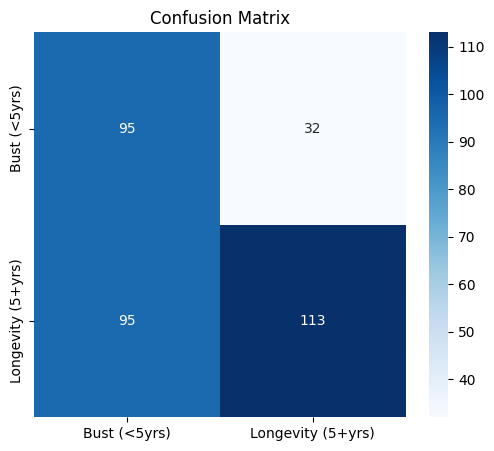

=== Classification Report ===
                   precision    recall  f1-score   support

     Bust (<5yrs)       0.50      0.75      0.60       127
Longevity (5+yrs)       0.78      0.54      0.64       208

         accuracy                           0.62       335
        macro avg       0.64      0.65      0.62       335
     weighted avg       0.67      0.62      0.62       335

Precision: 0.7793
Recall: 0.5433


In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bust (<5yrs)', 'Longevity (5+yrs)'],
            yticklabels=['Bust (<5yrs)', 'Longevity (5+yrs)'])
plt.title('Confusion Matrix')
plt.show()

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Bust (<5yrs)', 'Longevity (5+yrs)']))

print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

Assumptions & Executive Summary

In [6]:
print("=== Naive Bayes Independence Assumption ===")
print("""Gaussian Naive Bayes assumes all features are independent.
However, in basketball, features like Points Per Game (PTS) and Field Goals Made (FGM)
are highly correlated (more shots attempted usually leads to more points).
This violation can make probability estimates less reliable, but the model often still performs reasonably well.""")

print("\n=== Executive Summary for NBA Scouting Department ===")
print("""The GaussianNB model predicts whether a rookie will last 5+ years in the NBA.
Key strengths: Fast, probabilistic output, good at identifying high-volume scorers.
Limitations: Assumes feature independence which is not true in real basketball stats.
Recommendation: Use model as initial screening tool. Combine with expert scouting for players near decision boundary.""")

=== Naive Bayes Independence Assumption ===
Gaussian Naive Bayes assumes all features are independent.
However, in basketball, features like Points Per Game (PTS) and Field Goals Made (FGM) 
are highly correlated (more shots attempted usually leads to more points).
This violation can make probability estimates less reliable, but the model often still performs reasonably well.

=== Executive Summary for NBA Scouting Department ===
The GaussianNB model predicts whether a rookie will last 5+ years in the NBA.
Key strengths: Fast, probabilistic output, good at identifying high-volume scorers.
Limitations: Assumes feature independence which is not true in real basketball stats.
Recommendation: Use model as initial screening tool. Combine with expert scouting for players near decision boundary.
